In [1]:
#SCRIPT PARA UNIR LAS 2 ZONIFICACIONES Y EVALUAR EL CAMBIO EN LAS ZONAS DE EXCLUSIÓN
import geopandas as gpd
from itables import init_notebook_mode, show
import numpy as np
#Cargar las capas de zonificación anterior y actual

#Parámetros
ruta_zma_anterior = r'C:/O/OneDrive - SERINGTEC/zecl/PROYECTOS/RUBIALES/SHP/Zonificacion/ZonManAmbRub_20250731/ZonManAmbRub_20250731.shp'
ruta_zma_actual = r'C:/O/OneDrive - SERINGTEC/zecl/PROYECTOS/RUBIALES/SHP/Zonificacion/ZonManAmbRub_20260410/ZonManAmbRub_20260410.shp'
ruta_capa_salida = r'C:/O/OneDrive - SERINGTEC/zecl/PROYECTOS/RUBIALES/SHP/Analisis/ZMA_20250731_vs_20260410.shp'

#Leer las capas
print('Leyendo las capas...')
capa_zma_anterior = gpd.read_file(ruta_zma_anterior)
capa_zma_actual = gpd.read_file(ruta_zma_actual)

#Función para disolver y explotar capas
def limpiar_capa(capa):
    #Disolver por campo NOMENCLAT
    capa_limpia = (capa.dissolve(by='NOMENCLAT', as_index=False)).explode(index_parts=False).reset_index(drop=True)
    return capa_limpia
print('Capas leídas')

Leyendo las capas...
Capas leídas


In [2]:
#Limpiar capas
print('Limpiando capas de entrada...')
capa_zma_anterior = limpiar_capa(capa_zma_anterior)
capa_zma_actual = limpiar_capa(capa_zma_actual)
#Simplificar capas
print('Simplificando capas...')
capa_zma_anterior['geometry'] = capa_zma_anterior['geometry'].simplify(tolerance=0.1, preserve_topology=True)
capa_zma_actual['geometry'] = capa_zma_actual['geometry'].simplify(tolerance=0.1, preserve_topology=True)
print('Capas limpias y simplificadas')

Limpiando capas de entrada...
Simplificando capas...
Capas limpias y simplificadas


In [5]:
#Reproyectar las capas al EPSG: 3117
print('Reproyectando...')
capa_zma_anterior = capa_zma_anterior.to_crs(epsg=3117)
capa_zma_actual = capa_zma_actual.to_crs(epsg=3117)
print('Capas reproyectadas')

Reproyectando...
Capas reproyectadas


Haciendo filtros...
Uniendo máscaras
Máscara generada


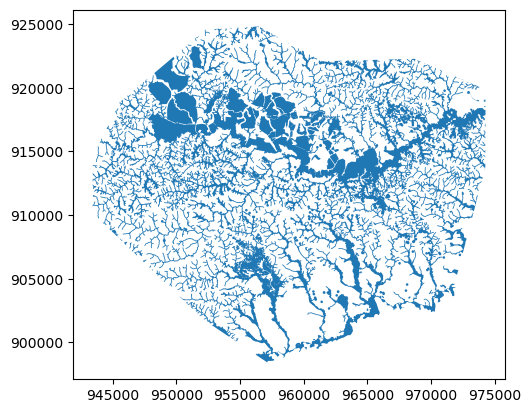

In [6]:
#Generar máscara de exclusiones
print('Haciendo filtros...')
excl_antes = capa_zma_anterior[capa_zma_anterior['NOMENCLAT'] == 'Exclusión'].copy()
excl_ahora = capa_zma_anterior[capa_zma_anterior['NOMENCLAT'] == 'Exclusión'].copy()
print('Uniendo máscaras')
exclusion_mask = (gpd.overlay(excl_antes, excl_ahora,how='union')).dissolve(as_index=False)
exclusion_mask.plot()
print('Máscara generada')

In [ ]:
#Unión entre las capas
#Extracción de las áreas donde hay exclusiones ya sea antes o ahora
print('Aplicando extracción a cada epoca...')
capa_zma_anterior = gpd.overlay(capa_zma_anterior, exclusion_mask, how='intersection', keep_geom_type=True)
capa_zma_actual = gpd.overlay(capa_zma_actual, exclusion_mask, how='intersection', keep_geom_type=True)
print('Uniendo exclusiones...')
union = gpd.overlay(capa_zma_anterior,capa_zma_actual, how='union')
union = limpiar_capa(union)
print('Unión generada')

Aplicando extracción a cada epoca...


In [ ]:
#Agregar campo de cambios y evaluarlo según las condiciones correspondientes
print('Evaluando cambios...')
condiciones = [
    (union['NOMENCLAT_1'] == 'Exclusión') & (union['NOMENCLAT_2'] != 'Exclusión'),
    (union['NOMENCLAT_1'] != 'Exclusión') & (union['NOMENCLAT_2'] == 'Exclusión'),
    (union['NOMENCLAT_1'] == 'Exclusión') & (union['NOMENCLAT_2'] == 'Exclusión')
]
valores = ['Disminuye','Aumenta','Se mantiene']
union['ZMA_ANTES'] = union['NOMENCLAT_1']
union['ZMA_AHORA'] = union['NOMENCLAT_2']
union['CAMBIO_ZMA'] = np.select(condiciones, valores, default='Modificada')

# Exportar capa resultante a SHP solo con los campos de interés
print('Exportando la capa...')
campos_interes = ['ZMA_ANTES', 'ZMA_AHORA', 'CAMBIO_ZMA', 'geometry']
capa_comp_zma = union_filtrada[campos_interes].copy()
capa_comp_zma['AREA_ha'] = (capa_comp_zma.geometry.area / 10000).round(6)
capa_comp_zma.to_file(ruta_capa_salida, driver='ESRI Shapefile')
capa_comp_zma.plot(
    column = 'CAMBIO_ZMA',
    cmap='Set1',
    legend=True,
    figsize=(10,10)
)
print('Script finalizado')